In [1]:
import pandas
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [4]:
import pandas as pd

# Create a list to hold all the data
data = []

# Parse Llama-2 7B data
model_name = "Llama-2 7B"
bits_data = [
    [3, 5.99, 74.66, 39.76, 76.88, 67.88, 55.16, 62.87],
    [2, 7.87, 74.05, 48.79, 61.64, 33.02, 67.09, 56.92],
    [1, 4082.93, 52.45, 25.88, 51.78, 22.44, 26.26, 35.76]
]
for row in bits_data:
    bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg = row
    data.append([model_name, bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg])

# Parse Llama-3 3B data
model_name = "Llama-3 3B"
bits_data = [
    [3, 11.59, 74.92, 49.45, 65.11, 36.69, 69.23, 59.08],
    [2, 16.90, 68.82, 39.76, 54.30, 27.39, 56.44, 47.57],
    [1, 387497.25, 54.41, 25.42, 51.70, 21.93, 25.55, 35.80]
]
for row in bits_data:
    bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg = row
    data.append([model_name, bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg])

# Parse TinyLlama 1.1B data
model_name = "TinyLlama 1.1B"
bits_data = [
    [3, 11.99, 66.21, 39.00, 50.28, 24.32, 41.96, 44.35],
    [2, 23.76, 60.45, 32.35, 52.88, 22.10, 35.90, 40.71],
    [1, 2297.22, 52.83, 25.68, 51.22, 21.50, 26.64, 35.58]
]
for row in bits_data:
    bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg = row
    data.append([model_name, bits, ppl, piqa, hellaswag, winogrande, arc_c, arc_easy, qa_avg])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    'Model', 'Bits', 'PPL', 'PIQA', 'HellaSwag', 'WinoGrande', 'ARC-c', 'ARC-Easy', 'QA Avg'
])

df

,Model,Bits,PPL,PIQA,HellaSwag,WinoGrande,ARC-c,ARC-Easy,QA Avg
0,Llama-2 7B,3,5.99,74.66,39.76,76.88,67.88,55.16,62.87
1,Llama-2 7B,2,7.87,74.05,48.79,61.64,33.02,67.09,56.92
2,Llama-2 7B,1,4082.93,52.45,25.88,51.78,22.44,26.26,35.76
3,Llama-3 3B,3,11.59,74.92,49.45,65.11,36.69,69.23,59.08
4,Llama-3 3B,2,16.90,68.82,39.76,54.30,27.39,56.44,47.57
5,Llama-3 3B,1,387497.25,54.41,25.42,51.70,21.93,25.55,35.80
6,TinyLlama 1.1B,3,11.99,66.21,39.00,50.28,24.32,41.96,44.35
7,TinyLlama 1.1B,2,23.76,60.45,32.35,52.88,22.10,35.90,40.71
8,TinyLlama 1.1B,1,2297.22,52.83,25.68,51.22,21.50,26.64,35.58


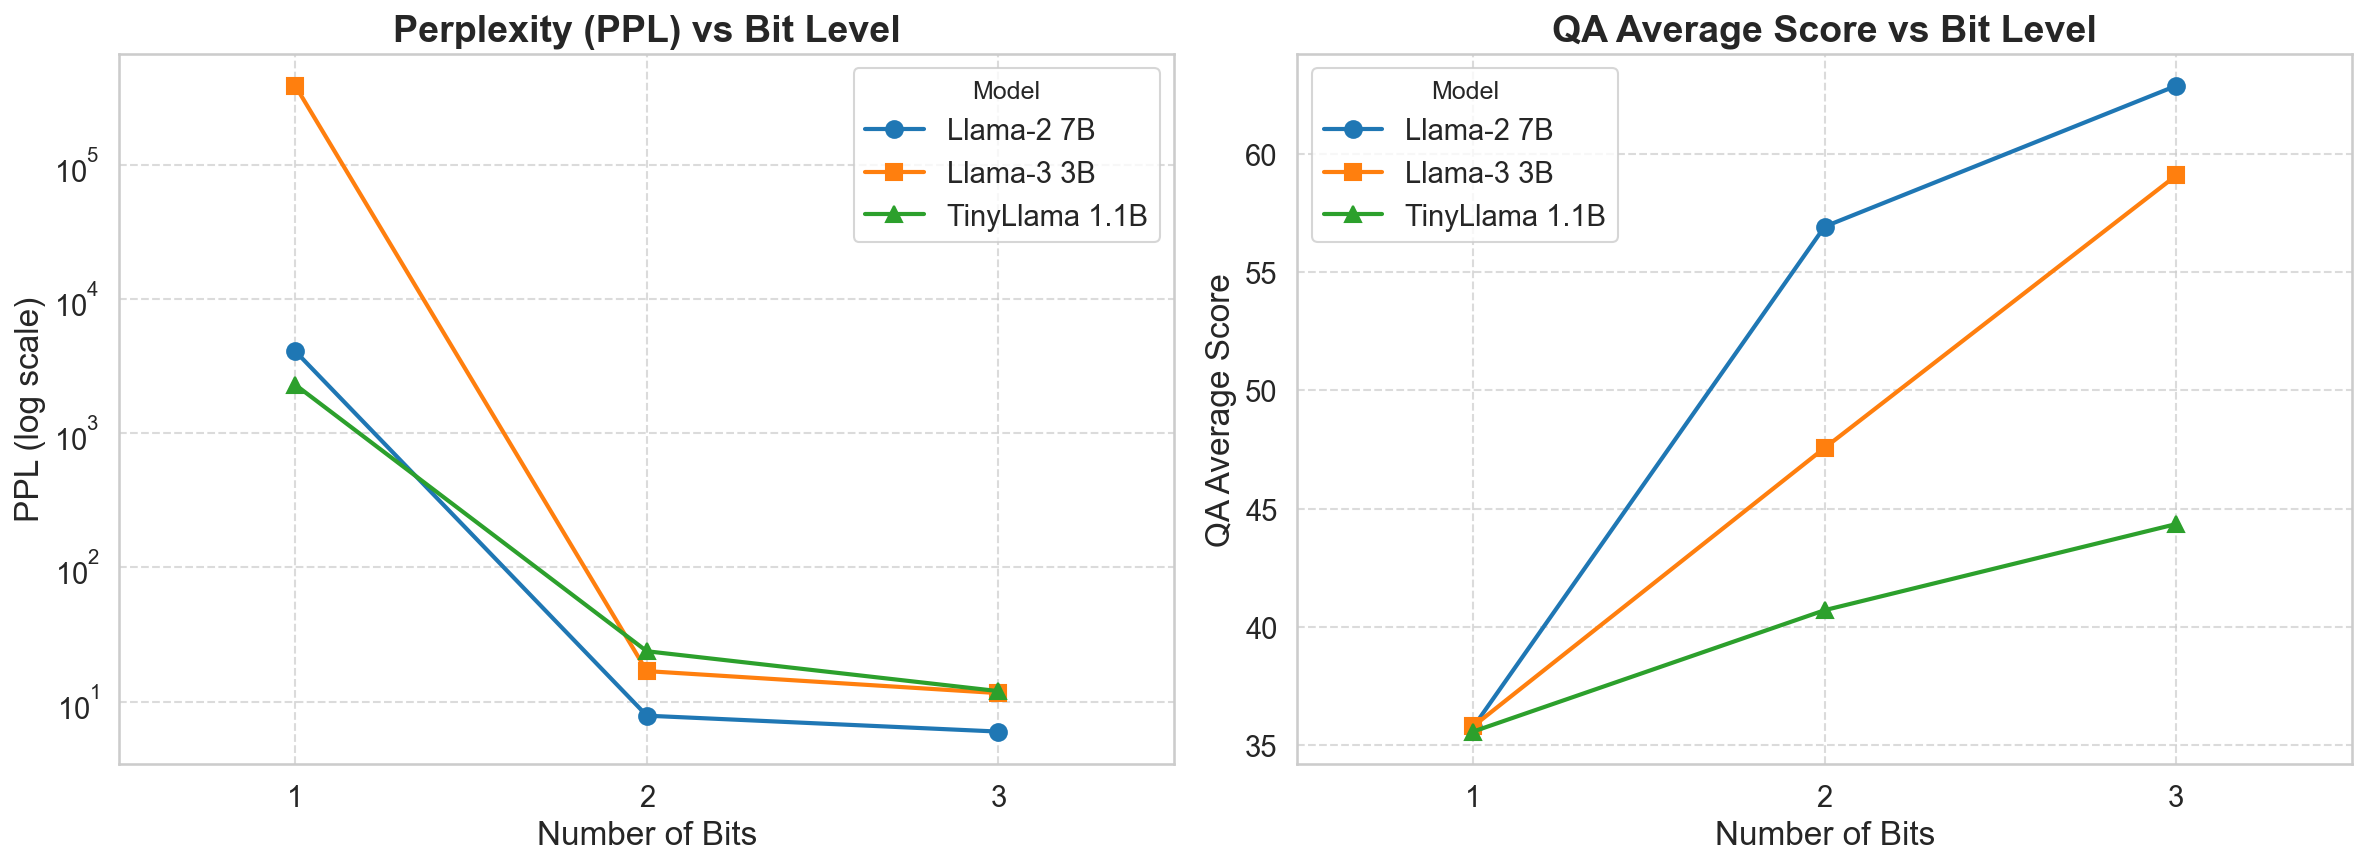

In [16]:
def plot_metric(dataframe, metric_name, use_log_scale=False):
    """
    Plot a metric for all models across different bit levels
    
    Parameters:
    dataframe (pd.DataFrame): DataFrame containing the model performance data
    metric_name (str): Name of the metric column to plot
    use_log_scale (bool): Whether to use log scale for y-axis
    
    Returns:
    matplotlib.figure.Figure: The generated figure
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Get unique models
    models = dataframe['Model'].unique()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Default matplotlib colors
    markers = ['o', 's', '^']  # Different markers for each model
    
    # Plot each model as a line
    for i, model in enumerate(models):
        model_data = dataframe[dataframe['Model'] == model]
        # Sort by bits (descending) to ensure correct line plotting
        model_data = model_data.sort_values('Bits', ascending=False)
        ax.plot(model_data['Bits'], model_data[metric_name], 
                marker=markers[i], label=model, color=colors[i], linewidth=2, markersize=8)
    
    # Set x-axis ticks to integers
    ax.set_xticks([1, 2, 3])
    ax.set_xlim(0.5, 3.5)
    
    # Apply log scale if requested
    if use_log_scale:
        ax.set_yscale('log')
        
    # Add grid, labels and title
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlabel('Number of Bits', fontsize=12)
    ax.set_ylabel(metric_name, fontsize=12)
    ax.set_title(f'{metric_name} vs Bit Level Across Models', fontsize=14, fontweight='bold')
    
    # Add legend
    ax.legend(title='Model', loc='best')
    
    # Ensure tight layout
    plt.tight_layout()
    
    return fig

# Set higher DPI for sharper plots
plt.rcParams['figure.dpi'] = 150
# Increase font sizes globally
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.titlesize'] = 20

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# For the first plot (PPL)
models = df['Model'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

# Plot PPL (with log scale) on the first axis
for i, model in enumerate(models):
    model_data = df[df['Model'] == model].sort_values('Bits', ascending=False)
    ax1.plot(model_data['Bits'], model_data['PPL'], 
            marker=markers[i], label=model, color=colors[i], linewidth=2, markersize=8)

ax1.set_yscale('log')
ax1.set_xticks([1, 2, 3])
ax1.set_xlim(0.5, 3.5)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xlabel('Number of Bits')
ax1.set_ylabel('PPL (log scale)')
ax1.set_title('Perplexity (PPL) vs Bit Level', fontweight='bold')
ax1.legend(title='Model', loc='best')

# Plot QA Avg on the second axis
for i, model in enumerate(models):
    model_data = df[df['Model'] == model].sort_values('Bits', ascending=False)
    ax2.plot(model_data['Bits'], model_data['QA Avg'], 
            marker=markers[i], label=model, color=colors[i], linewidth=2, markersize=8)

ax2.set_xticks([1, 2, 3])
ax2.set_xlim(0.5, 3.5)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_xlabel('Number of Bits')
ax2.set_ylabel('QA Average Score')
ax2.set_title('QA Average Score vs Bit Level', fontweight='bold')
ax2.legend(title='Model', loc='best')

plt.tight_layout()
plt.savefig("plots/benchmark_scaling.pdf", format="pdf", bbox_inches="tight")
plt.show()

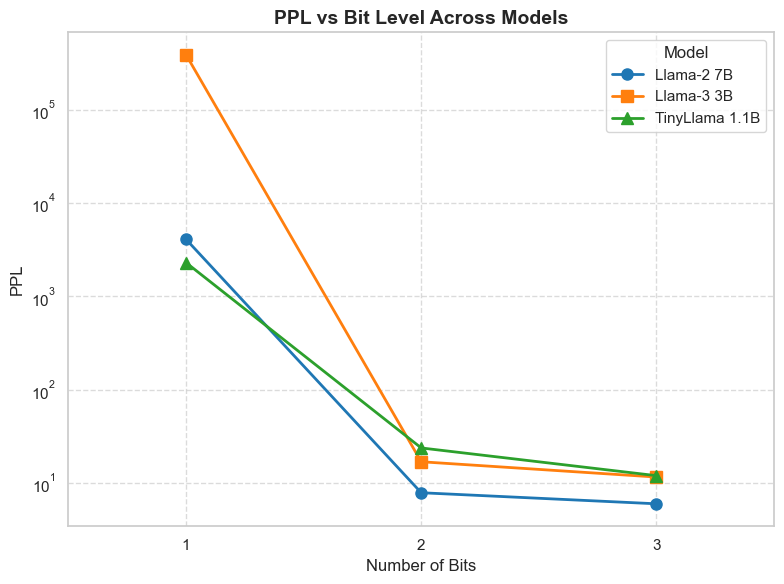

In [9]:
ppl_fig = plot_metric(df, 'PPL', use_log_scale=True)
plt.figure(ppl_fig.number)
plt.show()

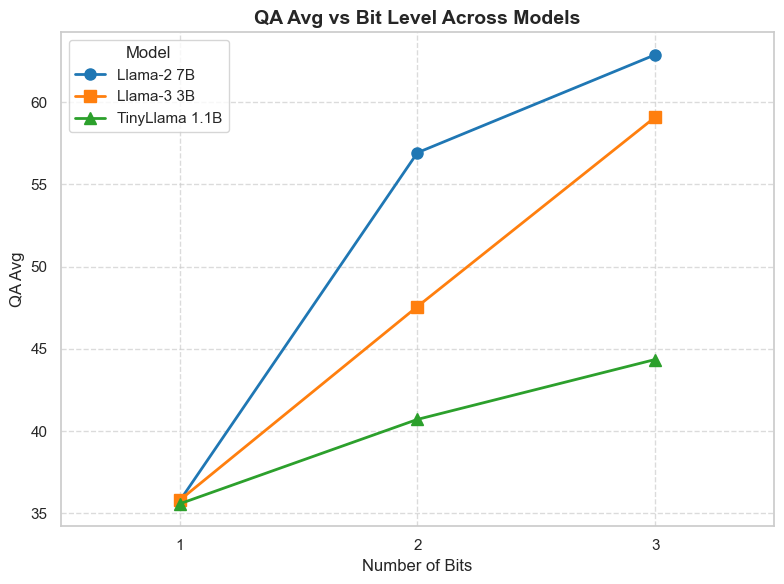

In [10]:
qa_avg_fig = plot_metric(df, 'QA Avg')
plt.figure(qa_avg_fig.number)
plt.show()